In [28]:
import h5py

filename = "/data/ws/VLN-CE/controller/object_react/custom_dataset/costmaps.h5"

h5 = h5py.File(filename,'r')

In [7]:
h5["ep_10684_0"].keys()

<KeysViewHDF5 ['img_masks', 'img_pls', 'size']>

In [16]:
h5["ep_10684_0"]["img_pls"]

<HDF5 dataset "img_pls": shape (20,), type "<f8">

In [21]:
h5["ep_10684_1"]["img_pls"][:].max()

78.11406707763672

In [26]:
import pickle

# Replace 'data.pkl' with your actual filename
with open('custom_dataset/ep_53446/traj_data.pkl', 'rb') as file:
    data = pickle.load(file)

In [28]:
len(data["position"])

15

Episode ep_9917: 107 frames
  FORWARD: 85 (79.4%)
  LEFT: 12 (11.2%)
  RIGHT: 10 (9.3%)


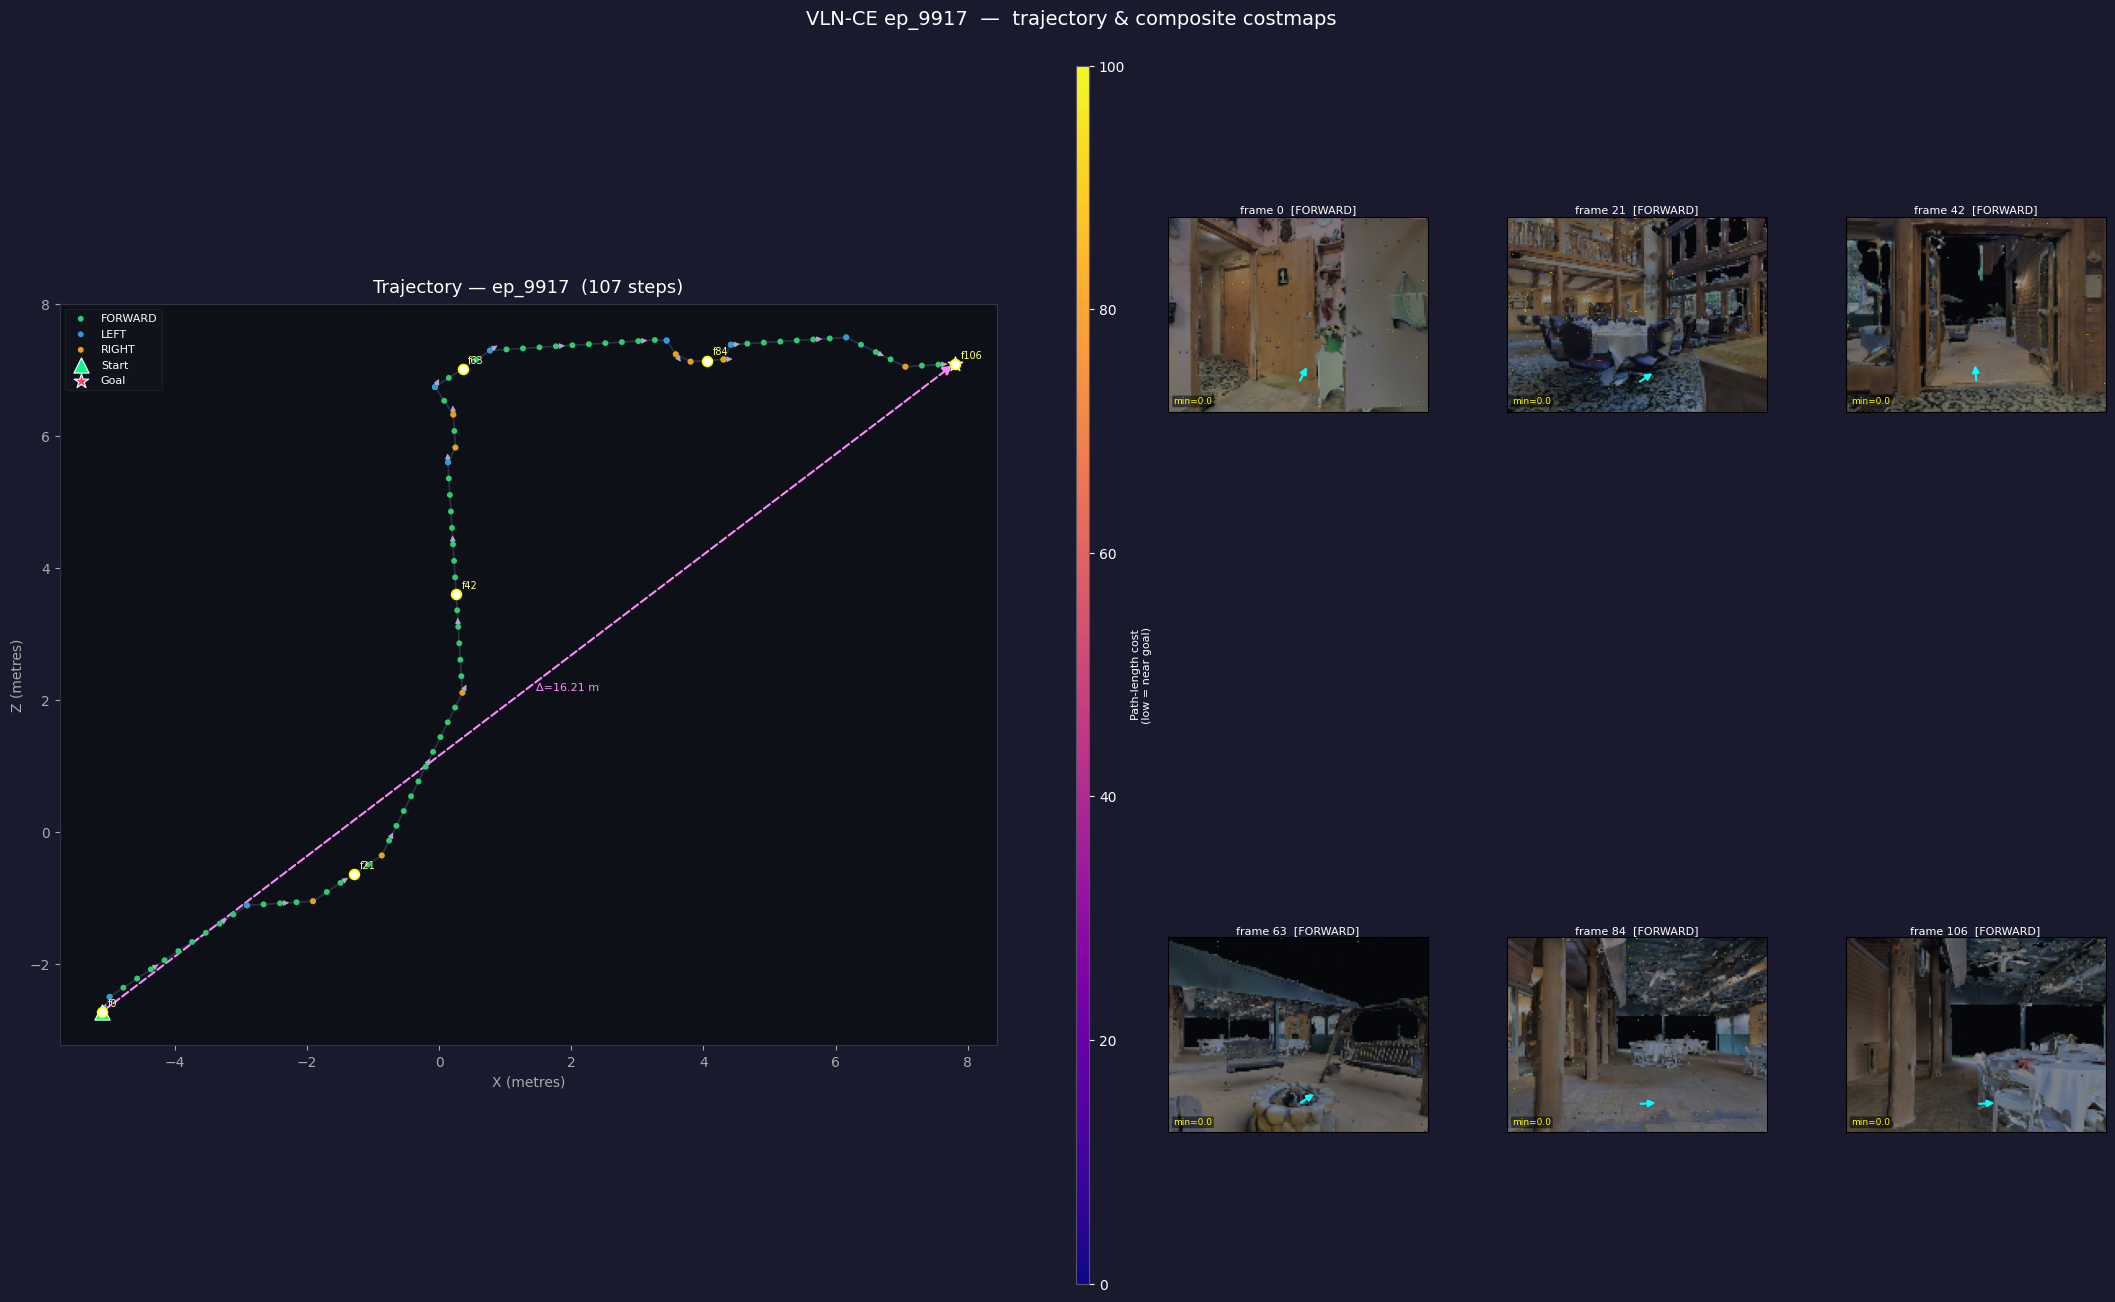

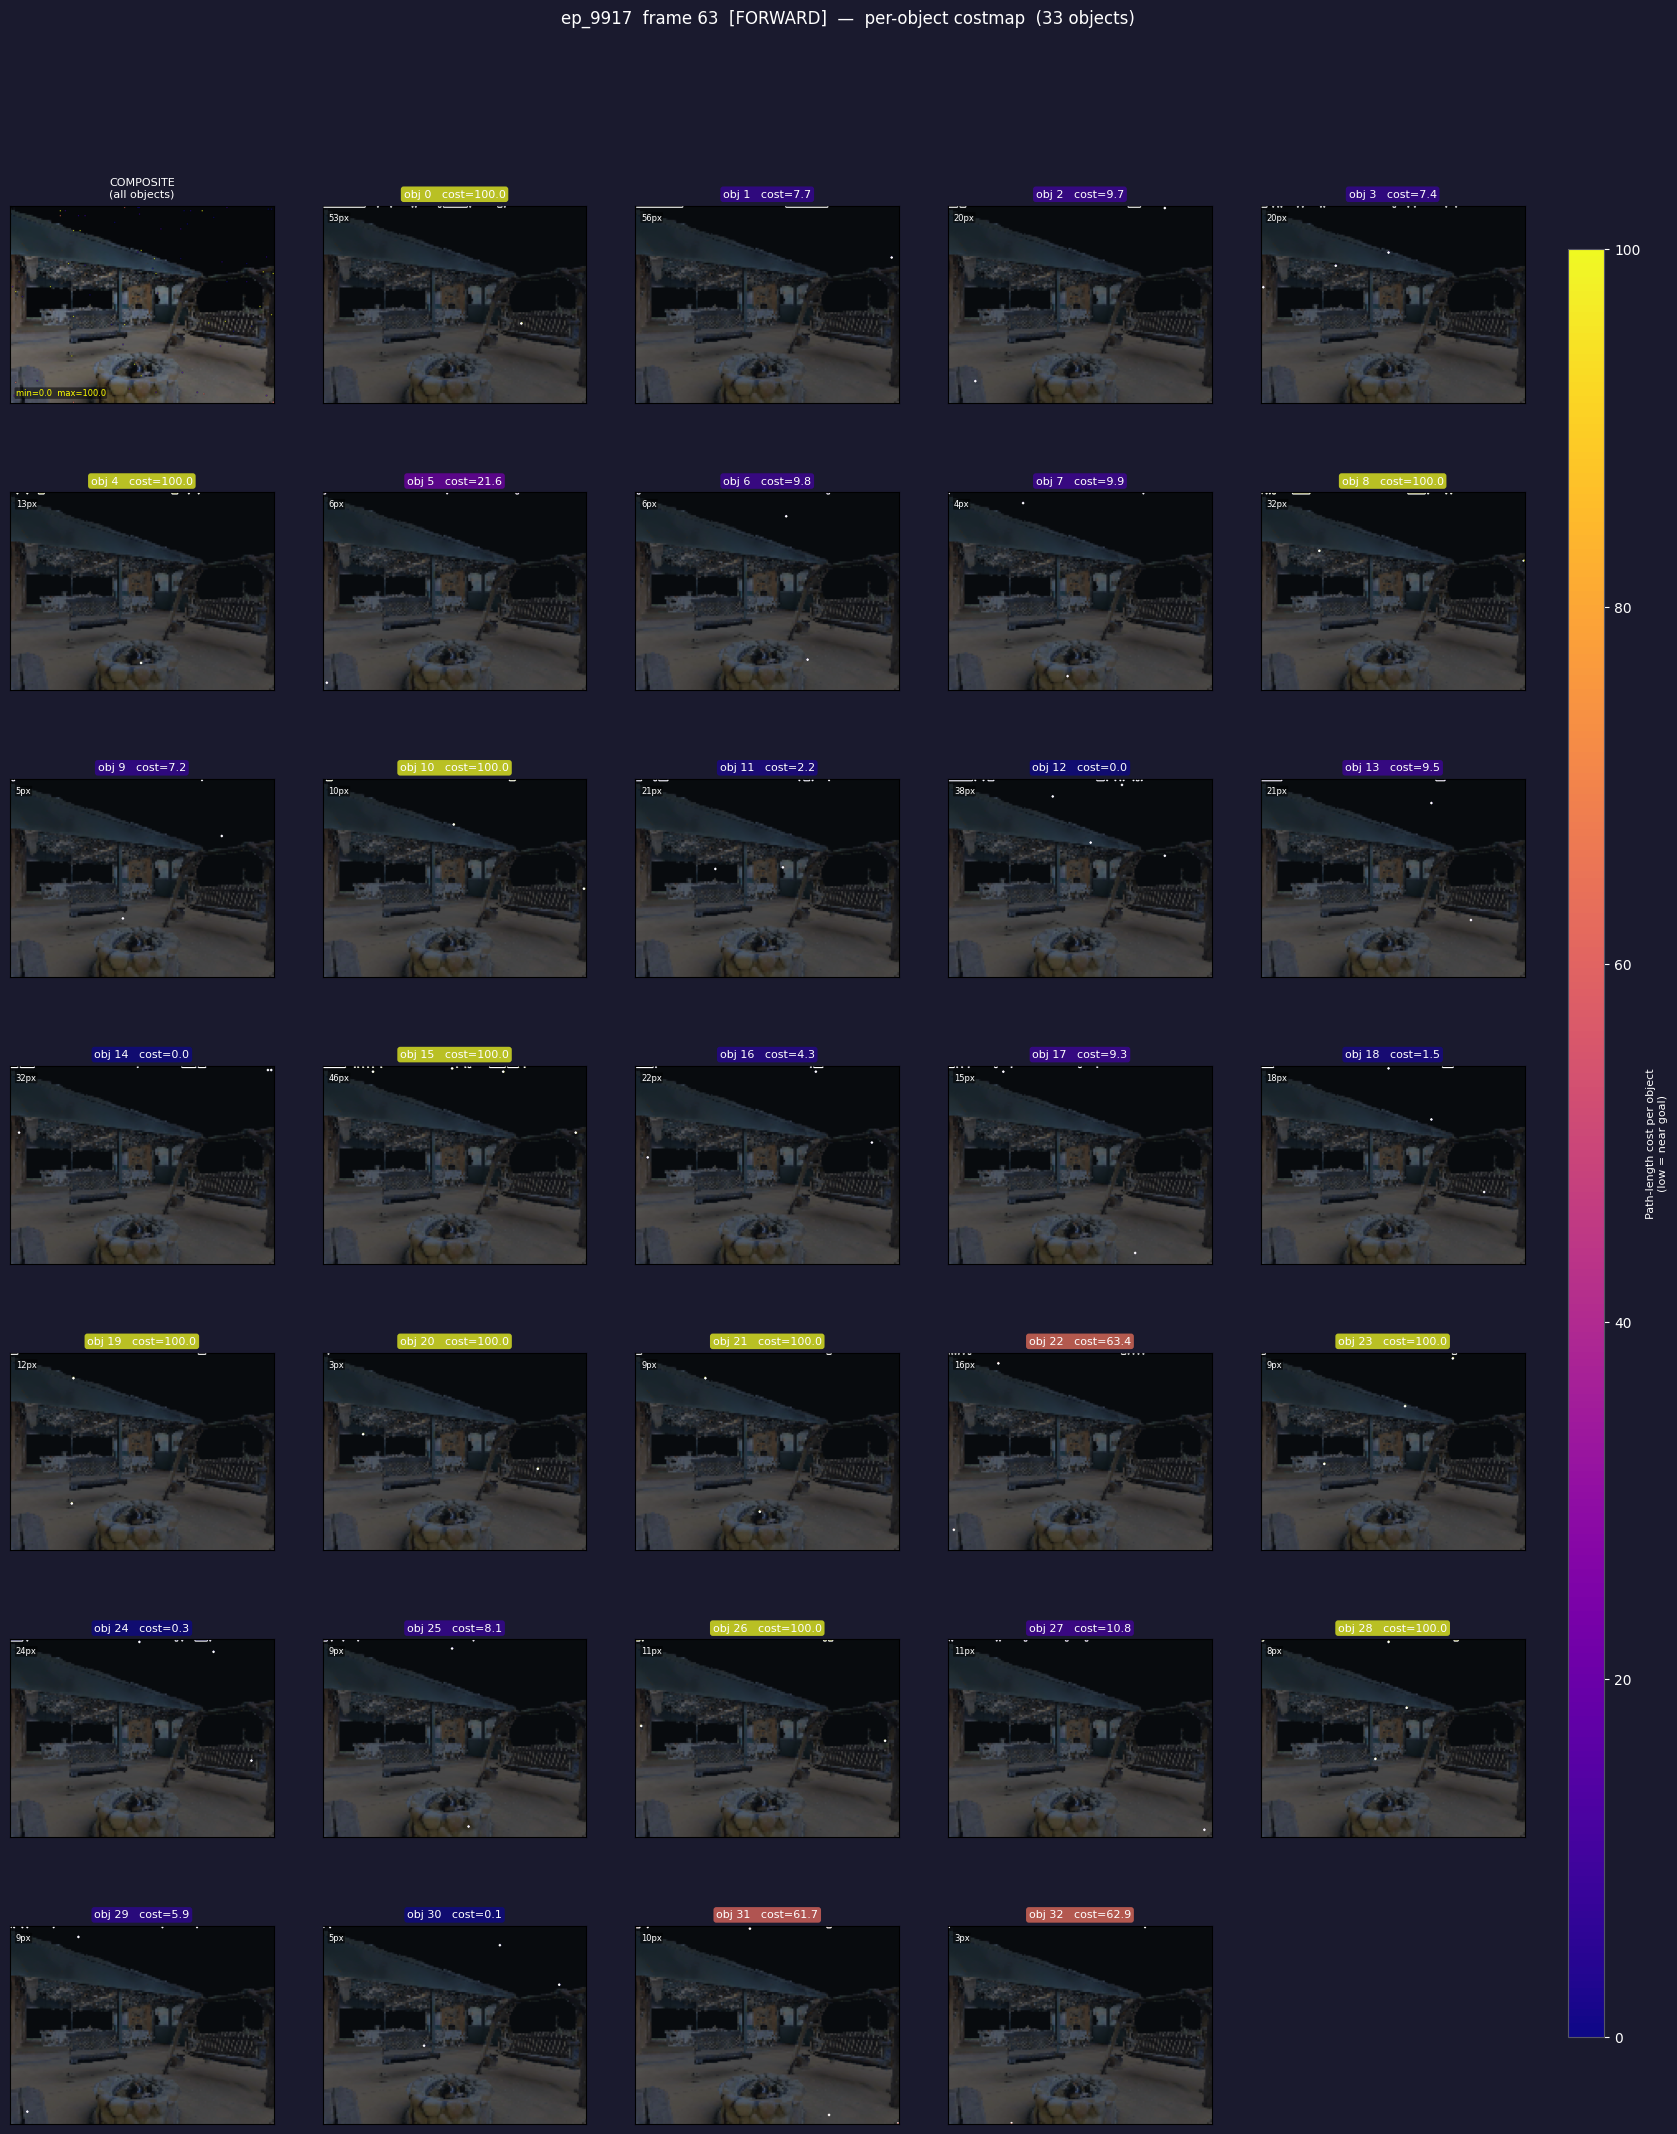

Per-object breakdown: 33 objects at frame 63


In [2]:
"""
Episode visualisation
=====================
Figure 1  — Trajectory + composite costmap panels (6 sampled frames)
Figure 2  — Per-object costmap breakdown for one selected frame
             Each sub-panel: RGB + one object mask tinted by its cost value
"""

import os
import pickle
import math

import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from PIL import Image

# ── paths ─────────────────────────────────────────────────────────────────────
EP_DIR     = "/data/ws/VLN-CE/controller/object_react/custom_dataset/ep_9917"
TRAJ_PKL   = os.path.join(EP_DIR, "traj_data.pkl")
IMAGES_DIR = os.path.join(EP_DIR, "images")
COSTMAP_H5 = "/data/ws/VLN-CE/controller/object_react/custom_dataset/costmaps.h5"
EP_NAME    = "ep_9917"

ACTION_LABELS  = {0: "STOP", 1: "FORWARD", 2: "LEFT", 3: "RIGHT"}
ACTION_COLOURS = {0: "#e74c3c", 1: "#2ecc71", 2: "#3498db", 3: "#f39c12"}

# ── helpers ───────────────────────────────────────────────────────────────────

def decode_masks_from_h5(grp, H, W):
    masks_grp = grp["img_masks"]
    K = len(masks_grp)
    masks = np.zeros((K, H, W), dtype=np.float32)
    for k in range(K):
        flat_idx = masks_grp[str(k)][()]          # 1-based flat pixel indices
        masks[k].flat[flat_idx - 1] = 1.0
    return masks                                  # (K, H, W)


def composite_costmap(masks, costs):
    K, H, W = masks.shape
    cost_map = np.full((H, W), fill_value=np.nan, dtype=np.float32)
    for k in np.argsort(costs):
        present = masks[k] > 0.5
        to_fill = present & np.isnan(cost_map)
        cost_map[to_fill] = costs[k]
    return cost_map


def overlay_rgba_on_ax(ax, rgb, cost_map, cmap_name="plasma"):
    """Overlay a (H,W) cost_map as a translucent heat layer on top of rgb."""
    valid = ~np.isnan(cost_map)
    if not valid.any():
        return
    lo, hi = np.nanmin(cost_map), np.nanmax(cost_map)
    norm_map = (cost_map - lo) / max(hi - lo, 1e-6)
    cmap = matplotlib.colormaps[cmap_name]
    rgba = cmap(norm_map)
    rgba[..., 3] = np.where(valid, 0.65, 0.0)
    rgba_img = (Image.fromarray((rgba * 255).astype(np.uint8))
                .resize((rgb.shape[1], rgb.shape[0]), Image.LANCZOS))
    ax.imshow(np.array(rgba_img) / 255.0, zorder=2)


# ── load trajectory ───────────────────────────────────────────────────────────
with open(TRAJ_PKL, "rb") as f:
    traj = pickle.load(f)

positions = traj["position"]
yaws      = traj["yaw"]
actions   = traj["action"]
N = len(positions)

print(f"Episode {EP_NAME}: {N} frames")
for u, c in zip(*np.unique(actions.astype(int), return_counts=True)):
    print(f"  {ACTION_LABELS.get(u, u)}: {c} ({100*c/N:.1f}%)")

sample_frames = np.linspace(0, N - 1, 6, dtype=int).tolist()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Trajectory + composite costmap
# ══════════════════════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(22, 14))
fig1.patch.set_facecolor("#1a1a2e")
gs1 = fig1.add_gridspec(
    2, 7, left=0.04, right=0.97, top=0.93, bottom=0.06,
    wspace=0.35, hspace=0.45,
    width_ratios=[1, 1, 1, 0.05, 1, 1, 1],
)

ax_traj = fig1.add_subplot(gs1[:, 0:3])
ax_traj.set_facecolor("#0d1117")
ax_traj.set_title(f"Trajectory — {EP_NAME}  ({N} steps)", color="white", fontsize=13, pad=8)
ax_traj.set_xlabel("X (metres)", color="#aaaaaa")
ax_traj.set_ylabel("Z (metres)", color="#aaaaaa")
ax_traj.tick_params(colors="#aaaaaa")
for sp in ax_traj.spines.values():
    sp.set_edgecolor("#333344")

x, z = positions[:, 0], positions[:, 1]
ax_traj.plot(x, z, color="#444466", linewidth=1.2, zorder=1, alpha=0.6)

for act_id, colour in ACTION_COLOURS.items():
    m = actions == act_id
    if m.any():
        ax_traj.scatter(x[m], z[m], c=colour, s=18, zorder=3,
                        label=ACTION_LABELS[act_id], edgecolors="none")

arrow_scale = 0.18
for t in range(0, N, 5):
    yw = float(yaws[t])
    ax_traj.annotate("", xy=(x[t] + arrow_scale*np.cos(yw), z[t] + arrow_scale*np.sin(yw)),
                     xytext=(x[t], z[t]),
                     arrowprops=dict(arrowstyle="-|>", color="#aaaacc", lw=0.8, mutation_scale=8),
                     zorder=4)

ax_traj.scatter([x[0]], [z[0]], c="#00ff88", s=120, zorder=5,
                marker="^", label="Start", edgecolors="white", linewidths=0.8)
ax_traj.scatter([x[-1]], [z[-1]], c="#ff4466", s=120, zorder=5,
                marker="*", label="Goal",  edgecolors="white", linewidths=0.8)

for sf in sample_frames:
    ax_traj.scatter([x[sf]], [z[sf]], c="white", s=50, zorder=6,
                    marker="o", edgecolors="yellow", linewidths=1.2)
    ax_traj.annotate(f"f{sf}", (x[sf], z[sf]),
                     textcoords="offset points", xytext=(4, 4),
                     color="#ffff88", fontsize=7)

ax_traj.annotate("", xy=(x[-1], z[-1]), xytext=(x[0], z[0]),
                 arrowprops=dict(arrowstyle="-|>", color="#ff88ff",
                                 lw=1.5, mutation_scale=14, linestyle="dashed"),
                 zorder=2)
dist_total = np.linalg.norm(positions[-1] - positions[0])
ax_traj.text((x[0]+x[-1])/2, (z[0]+z[-1])/2,
             f"  Δ={dist_total:.2f} m", color="#ff88ff", fontsize=8, va="center")
ax_traj.legend(loc="upper left", framealpha=0.25, fontsize=8,
               labelcolor="white", facecolor="#1a1a2e", edgecolor="#444455")
ax_traj.set_aspect("equal")

# --- composite costmap panels ------------------------------------------------
with h5py.File(COSTMAP_H5, "r") as h5:
    for panel_idx, frame_idx in enumerate(sample_frames):
        row = panel_idx // 3
        col = (panel_idx % 3) + 4
        ax = fig1.add_subplot(gs1[row, col])
        ax.set_facecolor("#0d1117")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        lbl = ACTION_LABELS.get(int(actions[frame_idx]), "?")
        ax.set_title(f"frame {frame_idx}  [{lbl}]", color="white", fontsize=8, pad=3)

        img_path = os.path.join(IMAGES_DIR, f"{frame_idx:05d}.png")
        rgb = np.array(Image.open(img_path).convert("RGB"))
        ax.imshow(rgb, alpha=0.55, zorder=1)

        key = f"{EP_NAME}_{frame_idx}"
        if key in h5:
            grp = h5[key]
            H_h5, W_h5 = grp["size"][()]
            costs = grp["img_pls"][()].astype(np.float32)
            masks = decode_masks_from_h5(grp, H_h5, W_h5)
            cost_map = composite_costmap(masks, costs)
            overlay_rgba_on_ax(ax, rgb, cost_map)

            valid = ~np.isnan(cost_map)
            if valid.any():
                min_cost = float(np.nanmin(cost_map))
                ax.text(3, rgb.shape[0]-4, f"min={min_cost:.1f}", color="yellow",
                        fontsize=6.5, va="bottom",
                        bbox=dict(boxstyle="round,pad=0.15", facecolor="black",
                                  alpha=0.5, edgecolor="none"))

            yaw_f = float(yaws[frame_idx])
            cx, cy = rgb.shape[1]*0.5, rgb.shape[0]*0.85
            alen = rgb.shape[1]*0.08
            ax.annotate("",
                        xy=(cx + alen*np.cos(yaw_f), cy - alen*np.sin(yaw_f)),
                        xytext=(cx, cy),
                        arrowprops=dict(arrowstyle="-|>", color="cyan",
                                        lw=1.5, mutation_scale=10),
                        zorder=5)
        else:
            ax.text(0.5, 0.5, f"No costmap\n{key}", transform=ax.transAxes,
                    ha="center", va="center", color="#888888", fontsize=8)

cbar_ax1 = fig1.add_subplot(gs1[:, 3])
cbar_ax1.set_facecolor("#1a1a2e")
sm1 = ScalarMappable(cmap="plasma", norm=Normalize(vmin=0, vmax=100))
sm1.set_array([])
cbar1 = fig1.colorbar(sm1, cax=cbar_ax1)
cbar1.set_label("Path-length cost\n(low = near goal)", color="white", fontsize=8)
cbar1.ax.yaxis.set_tick_params(color="white", labelcolor="white")
cbar1.outline.set_edgecolor("#555566")

fig1.suptitle(f"VLN-CE {EP_NAME}  —  trajectory & composite costmaps",
              color="white", fontsize=14, y=0.97)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Per-object costmap breakdown for a single selected frame
# ══════════════════════════════════════════════════════════════════════════════
# Pick the middle sample frame so it's representative of mid-episode context
detail_frame = sample_frames[len(sample_frames) // 2]
key_detail   = f"{EP_NAME}_{detail_frame}"

with h5py.File(COSTMAP_H5, "r") as h5:
    if key_detail not in h5:
        print(f"No costmap entry for {key_detail}")
    else:
        grp   = h5[key_detail]
        H_h5, W_h5 = grp["size"][()]
        costs = grp["img_pls"][()].astype(np.float32)      # (K,)
        masks = decode_masks_from_h5(grp, H_h5, W_h5)     # (K, H, W)
        K     = masks.shape[0]

        img_path = os.path.join(IMAGES_DIR, f"{detail_frame:05d}.png")
        rgb_base = np.array(Image.open(img_path).convert("RGB"))

        # Global cost range for a consistent colourbar across all objects
        global_lo, global_hi = float(costs.min()), float(costs.max())
        norm_global = Normalize(vmin=global_lo, vmax=global_hi)
        cmap_obj    = matplotlib.colormaps["plasma"]

        # Layout: K objects + 1 composite panel, up to 5 columns
        n_cols = min(5, K + 1)
        n_rows = math.ceil((K + 1) / n_cols)

        fig2, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(n_cols * 3.6, n_rows * 3.0 + 0.8),
        )
        fig2.patch.set_facecolor("#1a1a2e")
        axes = np.array(axes).reshape(-1)   # flatten regardless of shape

        action_lbl = ACTION_LABELS.get(int(actions[detail_frame]), "?")
        fig2.suptitle(
            f"{EP_NAME}  frame {detail_frame}  [{action_lbl}]"
            f"  —  per-object costmap  ({K} objects)",
            color="white", fontsize=12, y=1.01,
        )

        # --- Panel 0: composite (all objects together) -----------------------
        ax0 = axes[0]
        ax0.set_facecolor("#0d1117")
        ax0.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax0.set_title("COMPOSITE\n(all objects)", color="white", fontsize=8)
        ax0.imshow(rgb_base, alpha=0.5, zorder=1)
        cost_map_all = composite_costmap(masks, costs)
        overlay_rgba_on_ax(ax0, rgb_base, cost_map_all)
        valid_all = ~np.isnan(cost_map_all)
        if valid_all.any():
            ax0.text(3, rgb_base.shape[0]-4,
                     f"min={np.nanmin(cost_map_all):.1f}  max={np.nanmax(cost_map_all):.1f}",
                     color="yellow", fontsize=6, va="bottom",
                     bbox=dict(boxstyle="round,pad=0.15", facecolor="black",
                               alpha=0.5, edgecolor="none"))

        # --- Panels 1..K: individual objects ---------------------------------
        for k in range(K):
            ax = axes[k + 1]
            ax.set_facecolor("#0d1117")
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

            cost_val = float(costs[k])
            # Map this object's cost to a colour for the title bar background
            title_colour = cmap_obj(norm_global(cost_val))
            title_hex = matplotlib.colors.to_hex(title_colour)

            ax.set_title(f"obj {k}   cost={cost_val:.1f}", color="white",
                         fontsize=8,
                         bbox=dict(boxstyle="round,pad=0.25",
                                   facecolor=title_hex, alpha=0.75,
                                   edgecolor="none"))

            # Dim base RGB
            ax.imshow(rgb_base, alpha=0.35, zorder=1)

            # Build single-object cost map: pixels covered by this mask get cost_val
            single_mask = masks[k]                           # (H, W)
            single_cost = np.where(single_mask > 0.5, cost_val, np.nan).astype(np.float32)

            # Resize mask to rgb size for overlay
            mask_img = Image.fromarray((single_mask * 255).astype(np.uint8))
            mask_resized = np.array(mask_img.resize(
                (rgb_base.shape[1], rgb_base.shape[0]), Image.NEAREST)) / 255.0

            # Tint colour = plasma(normalised cost)
            rgba_fill = np.array(cmap_obj(norm_global(cost_val)))   # (4,)
            rgba_layer = np.ones((*rgb_base.shape[:2], 4), dtype=np.float32)
            rgba_layer[..., :3] = rgba_fill[:3]
            rgba_layer[..., 3]  = mask_resized * 0.70               # alpha from mask

            ax.imshow(rgba_layer, zorder=2)

            # Draw a thin white contour around the mask boundary
            from matplotlib.contour import QuadContourSet
            ax.contour(mask_resized, levels=[0.5], colors=["white"],
                       linewidths=0.8, zorder=3)

            # Pixel-count annotation
            n_pixels = int((single_mask > 0.5).sum())
            ax.text(3, 4, f"{n_pixels}px", color="white", fontsize=6, va="top",
                    bbox=dict(boxstyle="round,pad=0.1", facecolor="black",
                              alpha=0.5, edgecolor="none"))

        # Hide any unused axes
        for ax_extra in axes[K + 1:]:
            ax_extra.set_visible(False)

        # Shared colourbar
        fig2.subplots_adjust(left=0.03, right=0.88, top=0.92, bottom=0.04,
                             wspace=0.12, hspace=0.45)
        cbar_ax2 = fig2.add_axes([0.90, 0.08, 0.02, 0.82])
        sm2 = ScalarMappable(cmap="plasma", norm=norm_global)
        sm2.set_array([])
        cbar2 = fig2.colorbar(sm2, cax=cbar_ax2)
        cbar2.set_label("Path-length cost per object\n(low = near goal)",
                        color="white", fontsize=8)
        cbar2.ax.yaxis.set_tick_params(color="white", labelcolor="white")
        cbar2.outline.set_edgecolor("#555566")

        plt.show()
        print(f"Per-object breakdown: {K} objects at frame {detail_frame}")


In [4]:
"""
Bigger-bot trajectory visualiser
=================================
Shows for a chosen episode:
  • Top-down map with the GPS trajectory overlaid
  • Per-step yaw (heading) as a quiver overlay
  • Strip of sampled first-person images across the trajectory
  • Yaw and step-size plots over time
"""

import os, pickle, math
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image

# ── config ────────────────────────────────────────────────────────────────────
TRAJ_ROOT = "/data/ws/VLN-CE/controller/object_react/training/bigger_bot_0.3-sh_0.4/trajectories"
EPISODE   = "1UnKg1rAb8A_0002499_sofa_20_"   # change to any folder name
N_STRIP   = 8                                  # how many frames to show in the image strip

# ── load data ─────────────────────────────────────────────────────────────────
ep_dir = os.path.join(TRAJ_ROOT, EPISODE)

with open(os.path.join(ep_dir, "traj_data.pkl"), "rb") as f:
    traj = pickle.load(f)

positions = np.array(traj["position"])   # (N, 2)  [x, y_world]  y→north
yaw       = np.array(traj["yaw"])        # (N,)    radians, CCW-positive, LEFT↑

img_dir  = os.path.join(ep_dir, "images")
img_files = sorted(os.listdir(img_dir))
N = len(positions)

topdown_path = os.path.join(ep_dir, "topdownmap.jpg")
topdown = Image.open(topdown_path) if os.path.exists(topdown_path) else None

print(f"Episode : {EPISODE}")
print(f"Steps   : {N}")
print(f"x range : [{positions[:,0].min():.3f}, {positions[:,0].max():.3f}]  m")
print(f"y range : [{positions[:,1].min():.3f}, {positions[:,1].max():.3f}]  m")
print(f"yaw range: [{yaw.min():.3f}, {yaw.max():.3f}]  rad")

# ── step sizes & cumulative distance ─────────────────────────────────────────
dpos  = np.diff(positions, axis=0)
steps = np.linalg.norm(dpos, axis=1)          # (N-1,)
dyaw  = np.diff(yaw)                          # (N-1,)

# ── Figure 1 : trajectory + top-down map ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Episode: {EPISODE}", fontsize=11)

# — left: GPS path on blank axes (world coords) —
ax = axes[0]
sc = ax.scatter(positions[:, 0], positions[:, 1],
                c=np.arange(N), cmap="plasma", s=18, zorder=3, label="steps")
# quiver for heading direction
qstride = max(1, N // 30)
ax.quiver(positions[::qstride, 0], positions[::qstride, 1],
          np.cos(yaw[::qstride]), np.sin(yaw[::qstride]),
          scale=20, width=0.004, color="steelblue", alpha=0.7, label="heading")
ax.plot(positions[0, 0],  positions[0, 1],  "g^", ms=10, zorder=5, label="start")
ax.plot(positions[-1, 0], positions[-1, 1], "rs", ms=10, zorder=5, label="end")
plt.colorbar(sc, ax=ax, label="step index")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("GPS trajectory (world frame)")
ax.set_aspect("equal"); ax.legend(fontsize=8)

# — right: top-down map (if available) with trajectory overlaid —
ax2 = axes[1]
if topdown is not None:
    # normalise GPS coords → pixel coords using image extent
    td = np.array(topdown)
    H, W = td.shape[:2]
    x_min, x_max = positions[:, 0].min(), positions[:, 0].max()
    y_min, y_max = positions[:, 1].min(), positions[:, 1].max()
    pad = 0.1
    x_range = (x_max - x_min) or 1.0
    y_range = (y_max - y_min) or 1.0
    px = ((positions[:, 0] - x_min) / x_range) * W * (1 - 2*pad) + W * pad
    # image y-axis is flipped (top=0)
    py = (1.0 - (positions[:, 1] - y_min) / y_range) * H * (1 - 2*pad) + H * pad
    ax2.imshow(td)
    ax2.scatter(px, py, c=np.arange(N), cmap="plasma", s=14, zorder=3)
    ax2.plot(px[0], py[0],   "g^", ms=10, zorder=5, label="start")
    ax2.plot(px[-1], py[-1], "rs", ms=10, zorder=5, label="end")
    ax2.set_title("Top-down map + trajectory")
    ax2.legend(fontsize=8)
    ax2.axis("off")
else:
    ax2.text(0.5, 0.5, "topdownmap.jpg not found", ha="center", va="center")
    ax2.axis("off")

plt.tight_layout()
plt.savefig("/tmp/bb_traj_map.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → /tmp/bb_traj_map.png")

# ── Figure 2 : yaw & step-size over time ─────────────────────────────────────
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig2.suptitle("Per-step kinematics", fontsize=11)

ax3.plot(np.degrees(yaw), color="royalblue")
ax3.set_ylabel("Yaw (°)"); ax3.set_title("Heading over time"); ax3.grid(True, alpha=0.3)

ax4.bar(np.arange(len(steps)), steps, color="seagreen", width=1.0)
ax4.axhline(steps.mean(), color="red", linestyle="--", label=f"mean={steps.mean():.3f} m")
ax4.set_xlabel("Step index"); ax4.set_ylabel("Step size (m)")
ax4.set_title("Step size over time"); ax4.legend(); ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/bb_traj_kinematics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → /tmp/bb_traj_kinematics.png")

# ── Figure 3 : image strip ────────────────────────────────────────────────────
strip_indices = np.linspace(0, N - 1, N_STRIP, dtype=int)
fig3, axs = plt.subplots(1, N_STRIP, figsize=(3 * N_STRIP, 3))
fig3.suptitle("First-person frames (sampled)", fontsize=11)

for ax_i, idx in zip(axs, strip_indices):
    img = Image.open(os.path.join(img_dir, img_files[idx]))
    ax_i.imshow(img)
    ax_i.set_title(f"t={idx}\nyaw={math.degrees(yaw[idx]):.1f}°", fontsize=8)
    ax_i.axis("off")

plt.tight_layout()
plt.savefig("/tmp/bb_traj_strip.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → /tmp/bb_traj_strip.png")


Episode : 1UnKg1rAb8A_0002499_sofa_20_
Steps   : 35
x range : [-3.230, -0.356]  m
y range : [-0.114, 2.558]  m
yaw range: [-2.979, 3.103]  rad


/tmp/ipykernel_3853481/4156532928.py:97: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_3853481/4156532928.py:114: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved → /tmp/bb_traj_map.png
Saved → /tmp/bb_traj_kinematics.png
Saved → /tmp/bb_traj_strip.png


/tmp/ipykernel_3853481/4156532928.py:130: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Episode : 1UnKg1rAb8A_0002499_sofa_20_
Frames  : 35
H5 frames for this episode: 35  (range 0–34)
>>>>> <KeysViewHDF5 ['img_masks', 'img_pls', 'size']>
1UnKg1rAb8A_0002499_sofa_20__27/img_masks/0: [9360    1  119    2  118    3  117    4  116    5  115    5  115    4
  116    3  117    2  118    1 4299    1  119    1  119    2  119    1
  119    2  118    2   17   79   19    6   16  104   16  105   15  105
   15  106   15  105   14  107   13  107   13  108   12   40   16   52
   12   39   17   53   11   38   19   52   11   38   19   53   10   38
   19   53   10   37   20   54    9   37   20   54    9   37   20   55
    8   37   20   55    8   36   21   56    7   36   21   56    7   36
   21   57    6   36   21   57    6   35   22   58    5   35   22   58
    5   35   22   59    4   34   23   59    4   34   23   60    3   34
   23   60    3   34   23   61    2   34   23   61    2   34   23   62
    1   34   22   63    1]
1UnKg1rAb8A_0002499_sofa_20__27/img_masks/1: [10084     1   118    

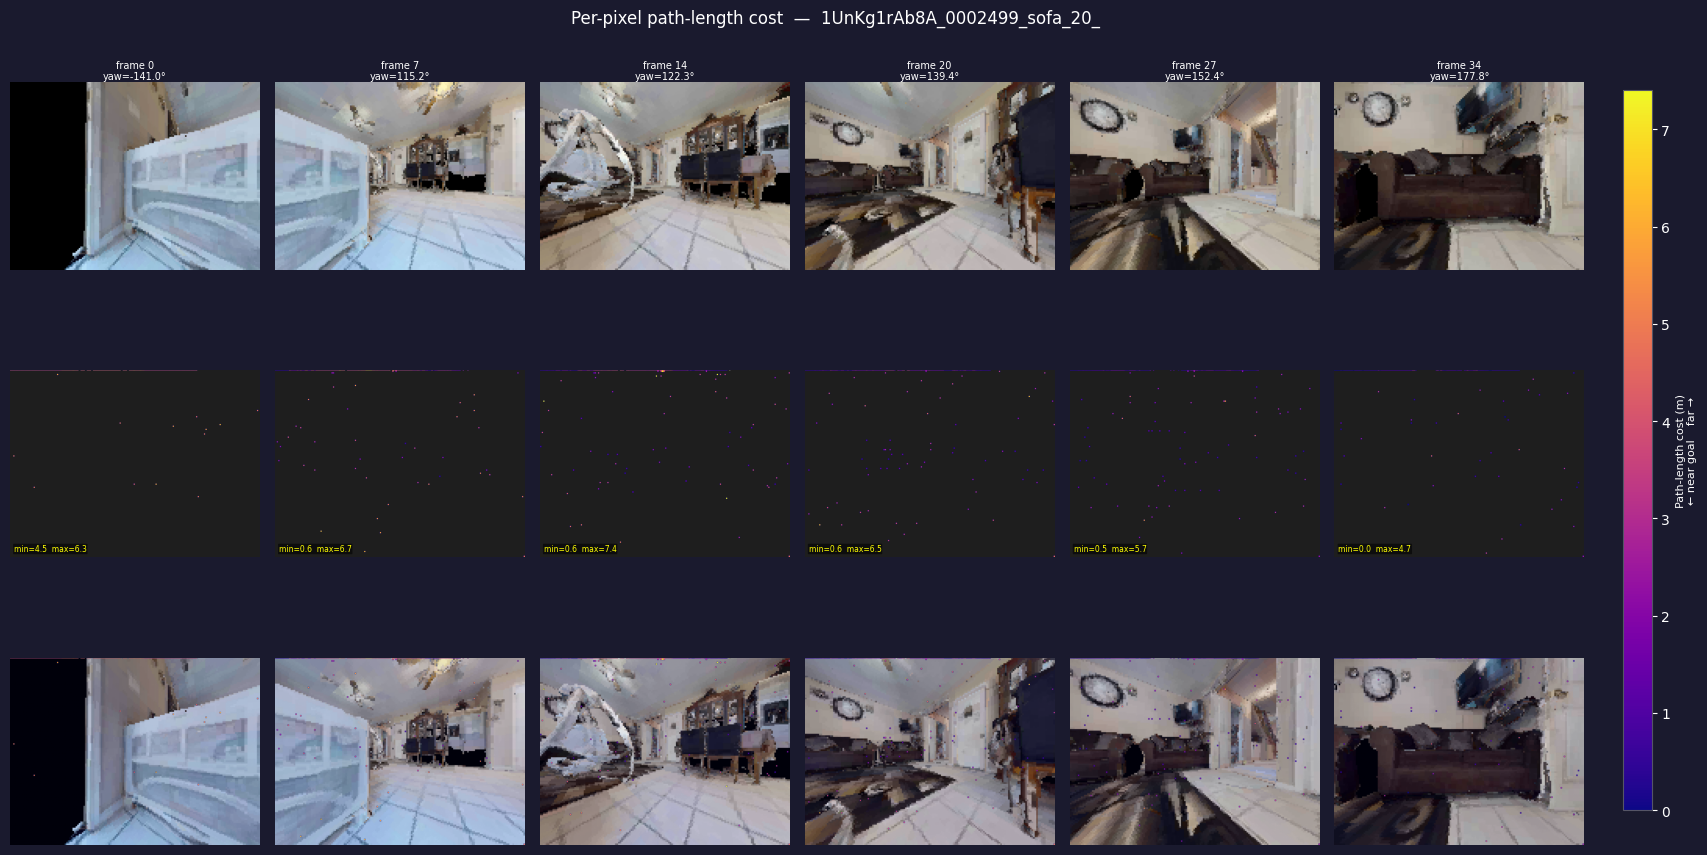

Saved → /tmp/per_pixel_cost_strip.png
Frame 20: 183 covered pixels (1.0%)  cost [0.64, 2.34, 6.51]  (min / mean / max)


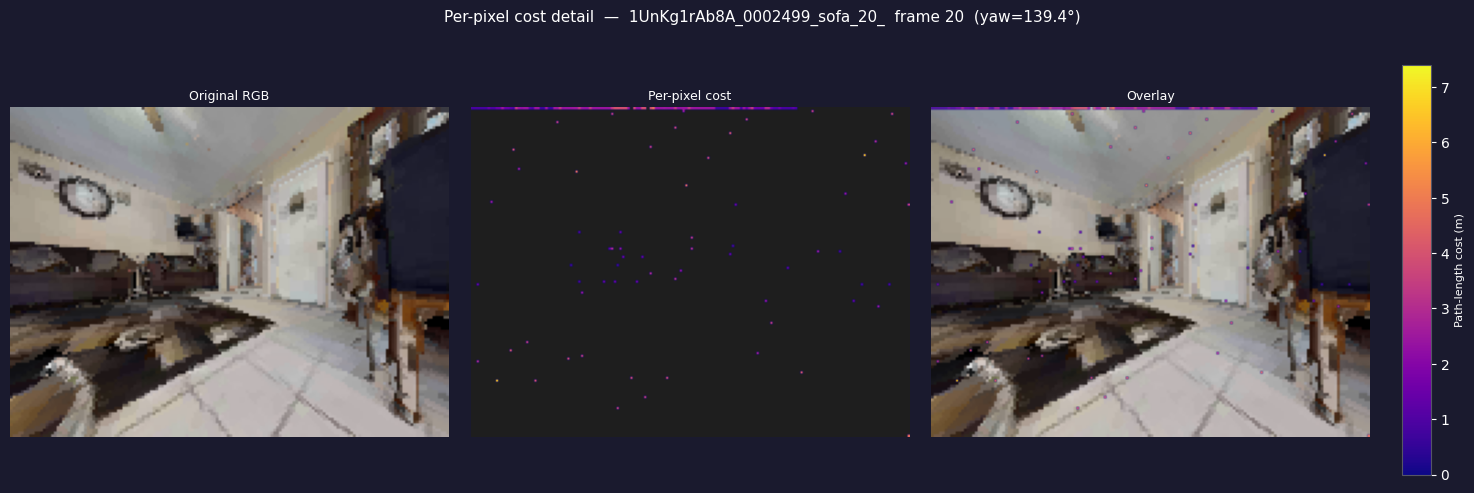

Saved → /tmp/per_pixel_cost_detail.png


In [32]:

"""
Per-pixel cost image
=====================
For every frame in a chosen episode, each pixel is assigned the path-length
cost (img_pls) of whichever detected object covers it.

  • Pixels covered by multiple objects → lowest cost wins
  • Pixels not covered by any object  → shown as background (light grey)

Outputs
-------
  • Figure 1 : grid of sampled frames  [RGB | cost heatmap | overlay]
  • Figure 2 : single-frame detail at a user-chosen step
  • /tmp/per_pixel_cost_*.png  saved copies
"""

import os, pickle, math
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from PIL import Image

# ── config ────────────────────────────────────────────────────────────────────
EPISODE   = "1UnKg1rAb8A_0002499_sofa_20_"          # episode name (prefix in H5)
TRAJ_ROOT = "/data/ws/VLN-CE/controller/object_react/training/bigger_bot_0.3-sh_0.4/trajectories"
H5_PATH   = "/data/ws/VLN-CE/controller/object_react/training/bigger_bot_0.3-sh_0.4/bigger_bot_0.3-sh_0.4_gt_topometric_e3d_masks_pls.h5"

DETAIL_FRAME = None   # set to an int to pick a specific frame for Figure 2,
                      # or leave None to auto-pick the middle sampled frame
N_STRIP      = 6      # how many sampled frames in Figure 1

# ── helpers ───────────────────────────────────────────────────────────────────

def build_per_pixel_cost(grp) -> np.ndarray:
    """
    Returns a float32 array of shape (H, W).
    Each pixel gets the minimum cost among all objects whose mask covers it.
    Pixels covered by no object are NaN.
    """
    H, W   = grp["size"][()]
    costs  = grp["img_pls"][()].astype(np.float32)   # (K,)
    masks  = grp["img_masks"]

    cost_img = np.full(H * W, fill_value=np.inf, dtype=np.float32)
    any_hit  = np.zeros(H * W, dtype=bool)

    for k in range(len(masks)):
        flat_idx = masks[str(k)][()]          # 1-based flat pixel indices
        pix      = flat_idx - 1               # 0-based
        cost_val = costs[k]
        # keep the minimum cost per pixel (nearest-to-goal wins)
        cost_img[pix] = np.minimum(cost_img[pix], cost_val)
        any_hit[pix]  = True

    cost_img[~any_hit] = np.nan
    return cost_img.reshape(H, W)


def cost_to_rgba(cost_img, vmin, vmax, cmap="plasma", bg_alpha=0.08):
    """
    Convert a (H,W) float32 cost image (with NaN for background) to RGBA uint8.
    Background pixels (NaN) are rendered nearly transparent.
    """
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    cmap_fn = matplotlib.colormaps[cmap]

    normed   = norm(np.nan_to_num(cost_img, nan=vmin))
    rgba     = cmap_fn(normed).astype(np.float32)              # (H,W,4)
    rgba[..., 3] = np.where(np.isnan(cost_img), bg_alpha, 0.85)
    return (rgba * 255).astype(np.uint8)


# ── load trajectory ───────────────────────────────────────────────────────────
ep_dir   = os.path.join(TRAJ_ROOT, EPISODE)
img_dir  = os.path.join(ep_dir, "images")

with open(os.path.join(ep_dir, "traj_data.pkl"), "rb") as f:
    traj = pickle.load(f)

positions = np.array(traj["position"])
yaws      = np.array(traj["yaw"])
N         = len(positions)

img_files = sorted(os.listdir(img_dir))

print(f"Episode : {EPISODE}")
print(f"Frames  : {N}")

# ── determine which H5 frames are available ───────────────────────────────────
with h5py.File(H5_PATH, "r") as h5:
    available = sorted(
        [int(k[len(EPISODE) + 1:]) for k in h5.keys() if k.startswith(EPISODE + "_")],
        key=lambda x: x
    )
print(f"H5 frames for this episode: {len(available)}  "
      f"(range {available[0]}–{available[-1]})")

sample_frames = np.round(np.linspace(0, len(available) - 1, N_STRIP)).astype(int)
sample_frames = [available[i] for i in sample_frames]

# ── build per-pixel cost images (once) ───────────────────────────────────────
cost_imgs   = {}    # frame_idx → (H, W) float32
global_min  =  np.inf
global_max  = -np.inf

with h5py.File(H5_PATH, "r") as h5:
    group= h5["1S7LAXRdDqK_0000000_plant_42__0"]["img_masks"]
    print(">>>>>", h5["1S7LAXRdDqK_0000000_plant_42__0"].keys())
    for member in group.keys():
            data = group[member][:]
            print(f"{key}/img_masks/{member}: {data}")
    frames_to_load = set(sample_frames)
    if DETAIL_FRAME is not None:
        frames_to_load.add(DETAIL_FRAME)
    for fi in frames_to_load:
        key = f"{EPISODE}_{fi}"
        if key in h5:
            ci = build_per_pixel_cost(h5[key])
            cost_imgs[fi] = ci
            valid = ci[~np.isnan(ci)]
            if valid.size:
                global_min = min(global_min, valid.min())
                global_max = max(global_max, valid.max())

print(f"Global cost range: [{global_min:.2f}, {global_max:.2f}]")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — sampled frames: RGB | cost heatmap | overlay
# ══════════════════════════════════════════════════════════════════════════════
n_cols  = N_STRIP
fig1, axes = plt.subplots(3, n_cols, figsize=(3.2 * n_cols, 9))
fig1.patch.set_facecolor("#1a1a2e")
fig1.suptitle(f"Per-pixel path-length cost  —  {EPISODE}",
              color="white", fontsize=12, y=0.99)

row_labels = ["RGB", "Cost heatmap", "Overlay"]
for r, lbl in enumerate(row_labels):
    axes[r, 0].set_ylabel(lbl, color="white", fontsize=9)

for col, fi in enumerate(sample_frames):
    rgb_path = os.path.join(img_dir, img_files[fi])
    rgb      = np.array(Image.open(rgb_path).convert("RGB"))

    # Row 0 – original RGB
    ax0 = axes[0, col]
    ax0.imshow(rgb)
    ax0.set_title(f"frame {fi}\nyaw={math.degrees(float(yaws[fi])):.1f}°",
                  color="white", fontsize=7, pad=2)
    ax0.axis("off")
    ax0.set_facecolor("#0d1117")

    # Row 1 – pure cost heatmap
    ax1 = axes[1, col]
    ax1.set_facecolor("#0d1117")
    ax1.axis("off")
    if fi in cost_imgs:
        ci = cost_imgs[fi]
        # interpolate to RGB size
        from PIL import Image as _Img
        ci_resized = np.array(
            _Img.fromarray(ci).resize((rgb.shape[1], rgb.shape[0]), _Img.BILINEAR)
        )
        norm = mcolors.Normalize(vmin=global_min, vmax=global_max, clip=True)
        cmap_fn = matplotlib.colormaps["plasma"]
        rgba_heat = cmap_fn(norm(np.nan_to_num(ci_resized, nan=global_min)))
        rgba_heat[..., 3] = np.where(np.isnan(ci_resized), 0.0, 1.0)
        # grey background for NaN
        bg = np.ones((*rgb.shape[:2], 3), dtype=np.float32) * 0.12
        ax1.imshow(bg, zorder=0)
        ax1.imshow(rgba_heat, zorder=1)
        valid = ci[~np.isnan(ci)]
        if valid.size:
            ax1.text(2, rgb.shape[0] - 3,
                     f"min={valid.min():.1f}  max={valid.max():.1f}",
                     color="yellow", fontsize=5.5, va="bottom",
                     bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.55, ec="none"))
    else:
        ax1.text(0.5, 0.5, "no data", ha="center", va="center",
                 color="#666677", transform=ax1.transAxes)

    # Row 2 – overlay on RGB
    ax2 = axes[2, col]
    ax2.set_facecolor("#0d1117")
    ax2.axis("off")
    ax2.imshow(rgb, zorder=0)
    if fi in cost_imgs:
        rgba_layer = cost_to_rgba(ci_resized, global_min, global_max)
        ax2.imshow(rgba_layer / 255.0, zorder=1)

# shared colourbar
fig1.subplots_adjust(left=0.07, right=0.89, top=0.94, bottom=0.03,
                     wspace=0.06, hspace=0.18)
cbar_ax = fig1.add_axes([0.91, 0.1, 0.015, 0.8])
sm = ScalarMappable(cmap="plasma",
                    norm=mcolors.Normalize(vmin=global_min, vmax=global_max))
sm.set_array([])
cb = fig1.colorbar(sm, cax=cbar_ax)
cb.set_label("Path-length cost (m)\n← near goal    far →",
             color="white", fontsize=8)
cb.ax.yaxis.set_tick_params(color="white", labelcolor="white")
cb.outline.set_edgecolor("#555566")

plt.savefig("/tmp/per_pixel_cost_strip.png", dpi=130, bbox_inches="tight",
            facecolor=fig1.get_facecolor())
plt.show()
print("Saved → /tmp/per_pixel_cost_strip.png")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — single-frame detail: full-res cost image + stats
# ══════════════════════════════════════════════════════════════════════════════
detail_frame = DETAIL_FRAME if DETAIL_FRAME is not None else sample_frames[len(sample_frames) // 2]

if detail_frame in cost_imgs:
    ci_d   = cost_imgs[detail_frame]
    rgb_d  = np.array(Image.open(os.path.join(img_dir, img_files[detail_frame])).convert("RGB"))

    # Resize cost image to match RGB resolution
    from PIL import Image as _Img
    ci_d_rs = np.array(
        _Img.fromarray(ci_d).resize((rgb_d.shape[1], rgb_d.shape[0]), _Img.BILINEAR)
    )
    # coverage mask preserved at original shape
    ci_d_mask = _Img.fromarray((~np.isnan(ci_d)).astype(np.uint8) * 255)
    ci_d_mask_rs = np.array(
        ci_d_mask.resize((rgb_d.shape[1], rgb_d.shape[0]), _Img.NEAREST)
    ).astype(bool)

    norm_d  = mcolors.Normalize(vmin=global_min, vmax=global_max, clip=True)
    cmap_fn = matplotlib.colormaps["plasma"]
    rgba_d  = cmap_fn(norm_d(np.nan_to_num(ci_d_rs, nan=global_min))).astype(np.float32)
    rgba_d[..., 3] = np.where(ci_d_mask_rs, 0.85, 0.0)

    fig2, axs = plt.subplots(1, 3, figsize=(16, 5))
    fig2.patch.set_facecolor("#1a1a2e")
    fig2.suptitle(
        f"Per-pixel cost detail  —  {EPISODE}  frame {detail_frame}"
        f"  (yaw={math.degrees(float(yaws[detail_frame])):.1f}°)",
        color="white", fontsize=11, y=1.01,
    )

    titles = ["Original RGB", "Per-pixel cost", "Overlay"]
    for ax in axs:
        ax.set_facecolor("#0d1117")
        ax.axis("off")
    for ax, t in zip(axs, titles):
        ax.set_title(t, color="white", fontsize=9)

    axs[0].imshow(rgb_d)

    bg2 = np.ones((*rgb_d.shape[:2], 3), dtype=np.float32) * 0.12
    axs[1].imshow(bg2, zorder=0)
    rgba_full = cmap_fn(norm_d(np.nan_to_num(ci_d_rs, nan=global_min))).astype(np.float32)
    rgba_full[..., 3] = np.where(ci_d_mask_rs, 1.0, 0.0)
    axs[1].imshow(rgba_full, zorder=1)

    axs[2].imshow(rgb_d, zorder=0)
    axs[2].imshow(rgba_d, zorder=1)

    fig2.subplots_adjust(left=0.03, right=0.88, top=0.93, bottom=0.04, wspace=0.05)
    cbar_ax2 = fig2.add_axes([0.90, 0.08, 0.018, 0.82])
    cb2 = fig2.colorbar(
        ScalarMappable(cmap="plasma", norm=norm_d), cax=cbar_ax2
    )
    cb2.set_label("Path-length cost (m)", color="white", fontsize=8)
    cb2.ax.yaxis.set_tick_params(color="white", labelcolor="white")
    cb2.outline.set_edgecolor("#555566")

    valid_d = ci_d[~np.isnan(ci_d)]
    coverage_pct = 100.0 * valid_d.size / ci_d.size
    print(f"Frame {detail_frame}: {valid_d.size} covered pixels "
          f"({coverage_pct:.1f}%)  "
          f"cost [{valid_d.min():.2f}, {valid_d.mean():.2f}, {valid_d.max():.2f}]  "
          f"(min / mean / max)")

    plt.savefig("/tmp/per_pixel_cost_detail.png", dpi=140, bbox_inches="tight",
                facecolor=fig2.get_facecolor())
    plt.show()
    print("Saved → /tmp/per_pixel_cost_detail.png")
else:
    print(f"Frame {detail_frame} not in H5.")


In [27]:
with h5py.File(H5_PATH, "r") as h5:
    data = h5["1S7LAXRdDqK_0000000_plant_42__0/img_pls"][:]
    for i, val in enumerate(data):
        print(f"[{i}]: {val:.6f}")

[0]: 14.392094
[1]: 14.165095
[2]: 14.160211
[3]: 14.921046
[4]: 15.091368
[5]: 15.091486
[6]: 14.896546
[7]: 14.294992
[8]: 15.047743
[9]: 13.606029
[10]: 13.025401
[11]: 13.884335
[12]: 13.997209
[13]: 13.322219
[14]: 14.132126
[15]: 12.606243
[16]: 14.075671
[17]: 13.115699
[18]: 11.932040
[19]: 12.109636
[20]: 12.472887


In [36]:
import h5py, numpy as np

H5_PATH    = ("/data/ws/VLN-CE/controller/object_react/training/"
              "bigger_bot_0.3-sh_0.4/"
              "bigger_bot_0.3-sh_0.4_gt_topometric_e3d_masks_pls.h5")
SAMPLE_KEY = "1S7LAXRdDqK_0000000_plant_42__0"

with h5py.File(H5_PATH, "r") as h5:
    grp   = h5[SAMPLE_KEY]
    H, W  = grp["size"][()]
    total = H * W
    for k in range(3):
        rle = grp["img_masks"][str(k)][()]
        even_sum = int(rle[0::2].sum())   # even-indexed runs
        odd_sum  = int(rle[1::2].sum())   # odd-indexed runs
        rle_total = int(rle.sum())
        print(f"obj {k}:  rle_sum={rle_total}  H*W={total}  "
              f"even_sum={even_sum}  odd_sum={odd_sum}  "
              f"rle[:7]={rle[:7].tolist()}")
    print(f"\nImage: {H}x{W} = {total} pixels")


obj 0:  rle_sum=19200  H*W=19200  even_sum=16093  odd_sum=3107  rle[:7]=[9360, 1, 119, 2, 118, 3, 117]
obj 1:  rle_sum=19200  H*W=19200  even_sum=17790  odd_sum=1410  rle[:7]=[10084, 1, 118, 78, 41, 80, 39]
obj 2:  rle_sum=19200  H*W=19200  even_sum=18721  odd_sum=479  rle[:7]=[16480, 16, 103, 11, 1, 5, 102]

Image: 120x160 = 19200 pixels


Image size  : 120x160  (120x160 RGB)
obj 0 cost  : 14.3921
C-order fg pixels : 3107
F-order fg pixels : 3107


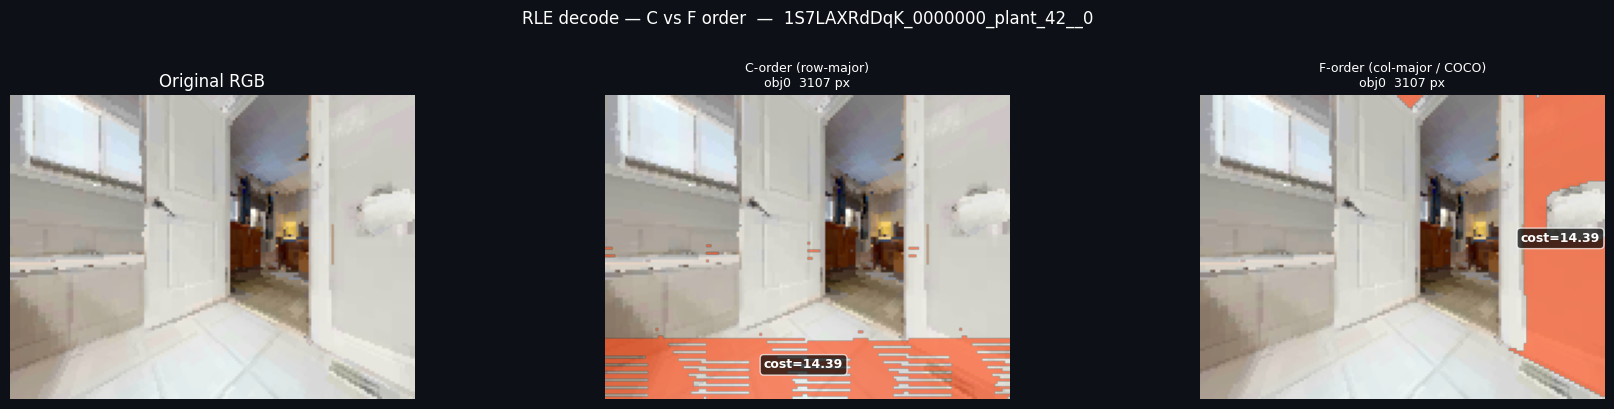

/tmp/ipykernel_4047796/707797533.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


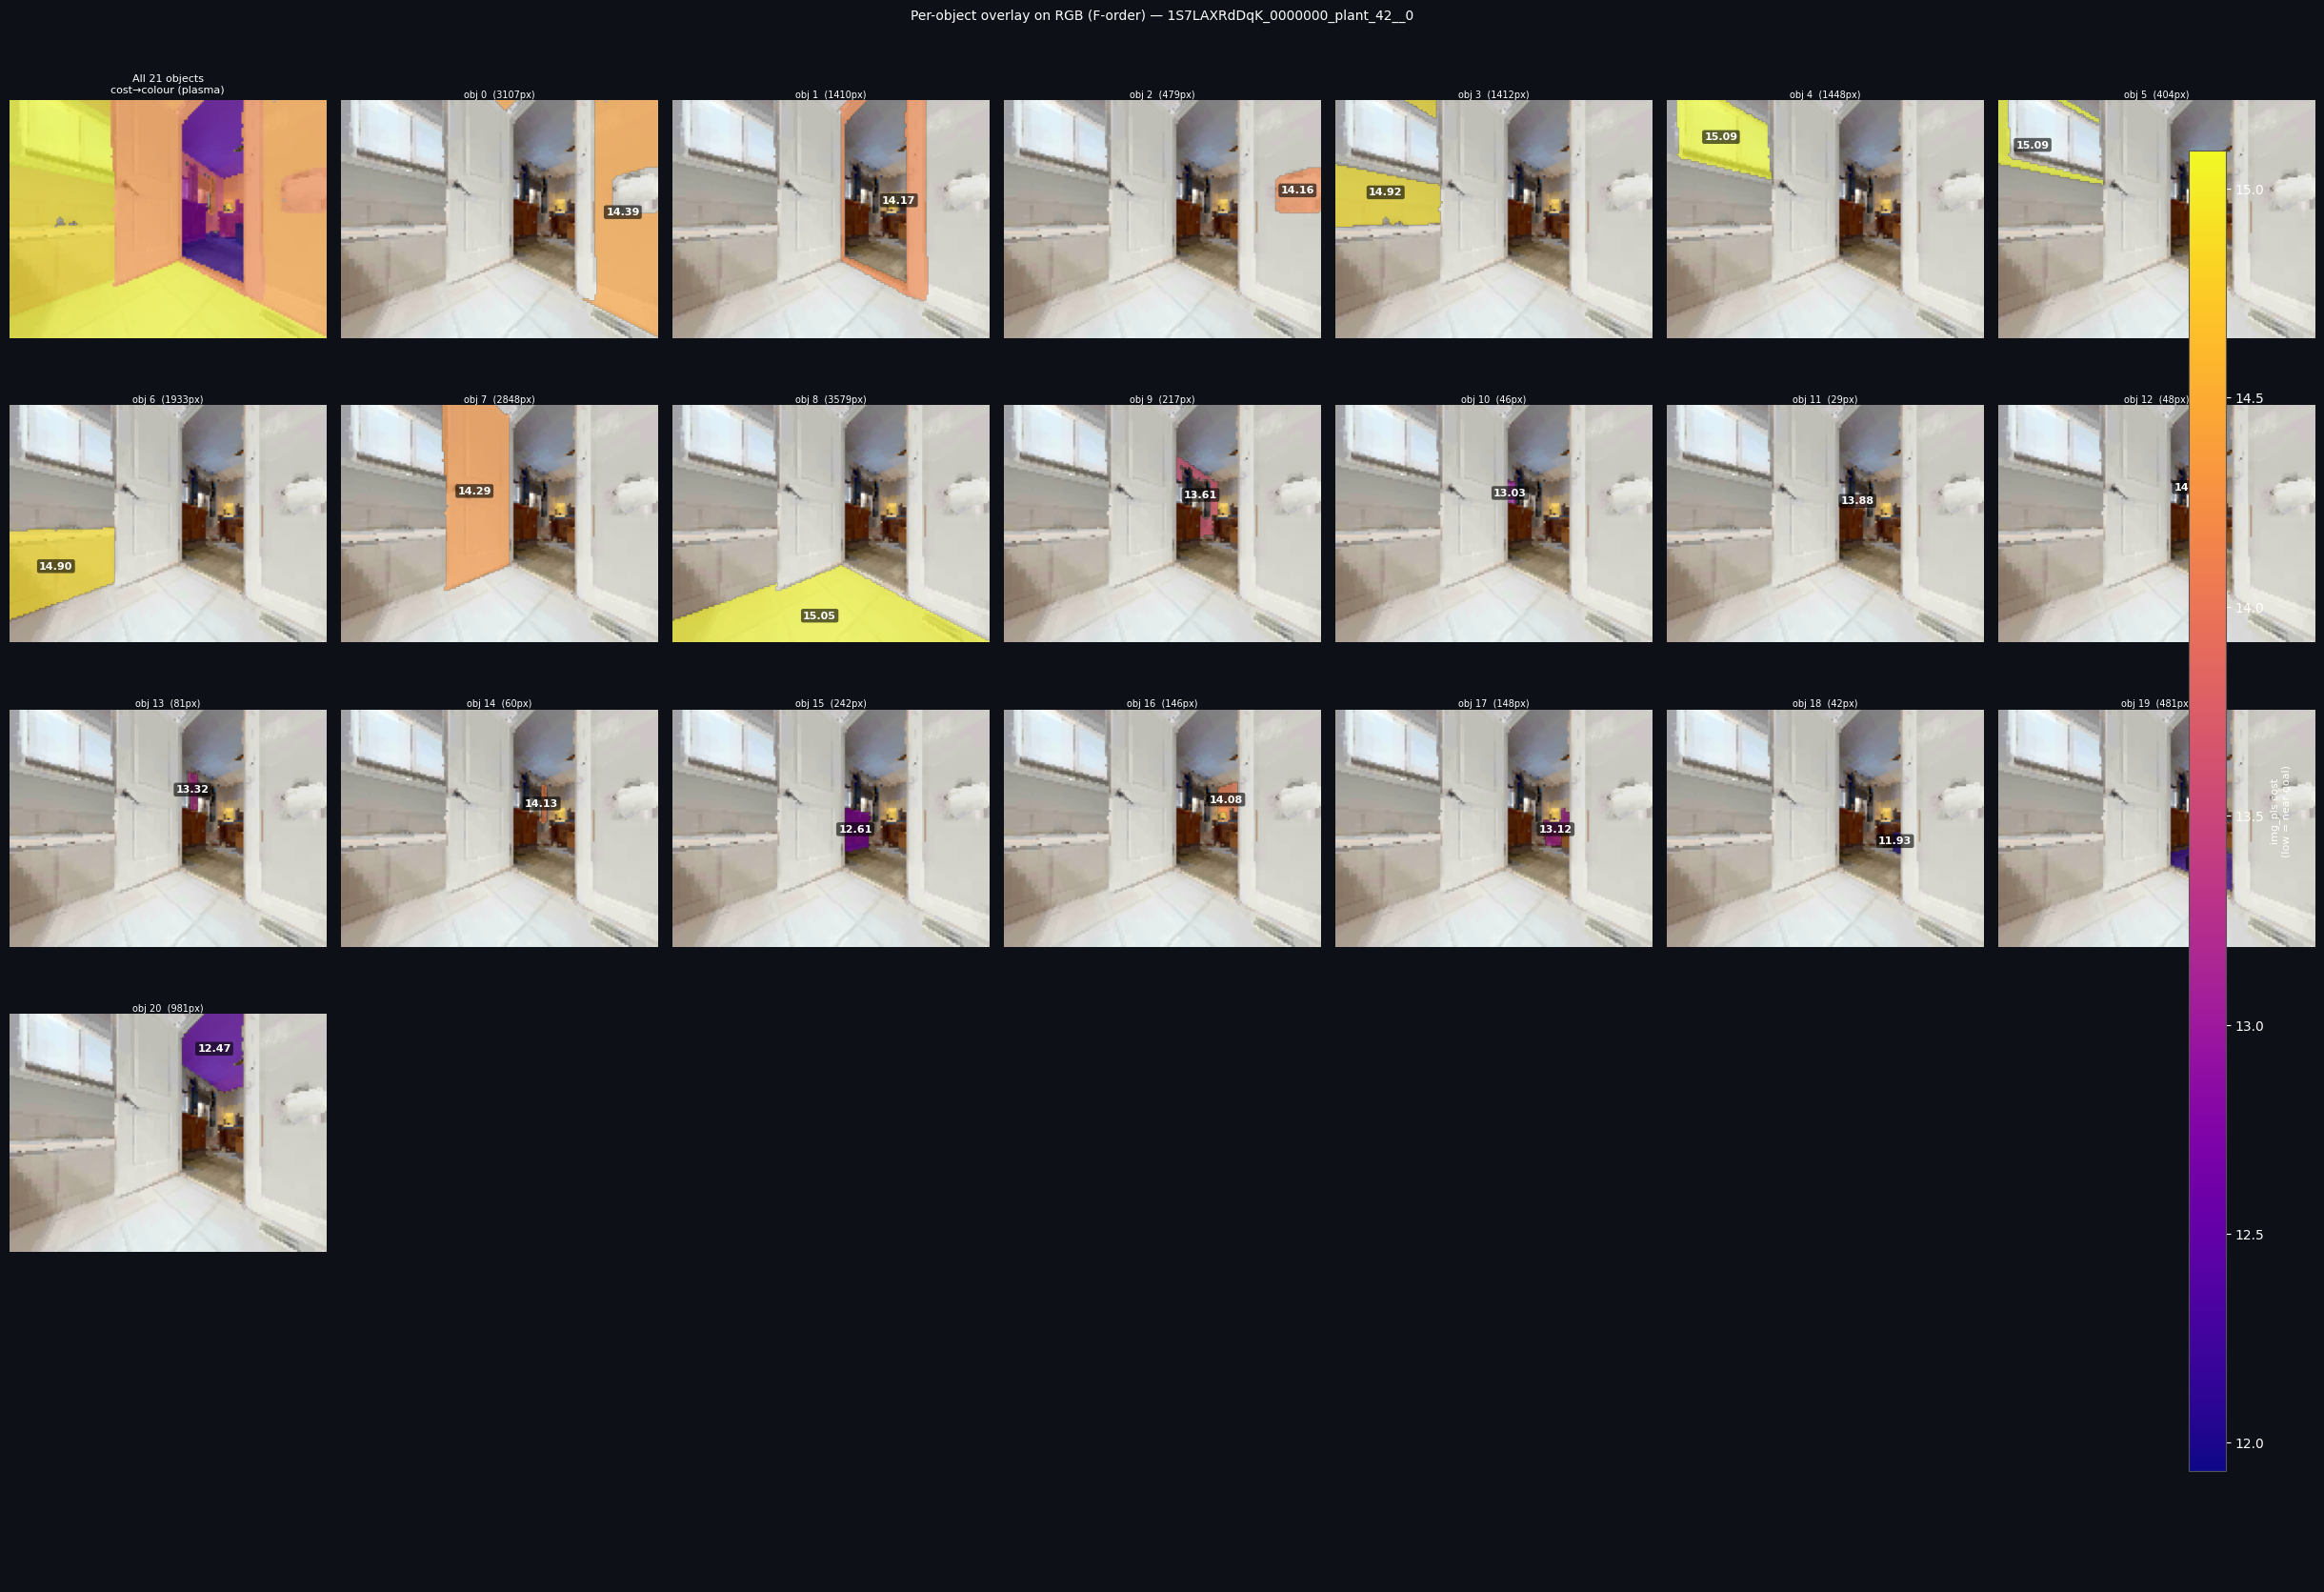

Saved → /tmp/rle_order_compare.png  and  /tmp/overlay_all_objects.png


In [39]:
"""
Single-mask overlay on the original RGB image
==============================================
Diagnose: try C-order vs F-order RLE reshape, then overlay each object's
mask + img_pls cost value on the real camera image.
"""

import h5py, numpy as np, matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from PIL import Image

H5_PATH    = ("/data/ws/VLN-CE/controller/object_react/training/"
              "bigger_bot_0.3-sh_0.4/"
              "bigger_bot_0.3-sh_0.4_gt_topometric_e3d_masks_pls.h5")
EP_FOLDER  = "1S7LAXRdDqK_0000000_plant_42_"   # trailing underscore
FRAME_IDX  = 0
SAMPLE_KEY = f"{EP_FOLDER}_{FRAME_IDX}"          # "...__0"
IMG_PATH   = (f"/data/ws/VLN-CE/controller/object_react/training/"
              f"bigger_bot_0.3-sh_0.4/trajectories/"
              f"{EP_FOLDER}/images/{FRAME_IDX:05d}.png")

rgb = np.array(Image.open(IMG_PATH).convert("RGB"))

with h5py.File(H5_PATH, "r") as h5:
    grp   = h5[SAMPLE_KEY]
    H, W  = grp["size"][()]
    costs = grp["img_pls"][()].astype(np.float32)
    K     = len(grp["img_masks"])
    rles  = {k: grp["img_masks"][str(k)][()] for k in range(K)}

# ── compare C-order vs F-order reshape for obj 0 ─────────────────────────────
def decode_rle_C(rle, H, W):
    """Row-major (C order) reshape — what we had before."""
    flat = np.zeros(H * W, dtype=np.uint8)
    pos, fg = 0, False
    for run in rle.tolist():
        if fg: flat[pos:pos+run] = 1
        pos += run; fg = not fg
    return flat.reshape(H, W)

def decode_rle_F(rle, H, W):
    """Column-major (Fortran / COCO standard) reshape."""
    flat = np.zeros(H * W, dtype=np.uint8)
    pos, fg = 0, False
    for run in rle.tolist():
        if fg: flat[pos:pos+run] = 1
        pos += run; fg = not fg
    return flat.reshape(W, H).T    # column-major

mask_C = decode_rle_C(rles[0], H, W)
mask_F = decode_rle_F(rles[0], H, W)
print(f"Image size  : {H}x{W}  ({rgb.shape[0]}x{rgb.shape[1]} RGB)")
print(f"obj 0 cost  : {costs[0]:.4f}")
print(f"C-order fg pixels : {mask_C.sum()}")
print(f"F-order fg pixels : {mask_F.sum()}")

# ── Row 1: comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.patch.set_facecolor("#0d1117")
for ax in axes: ax.axis("off"); ax.set_facecolor("#0d1117")

axes[0].imshow(rgb)
axes[0].set_title("Original RGB", color="white")

def overlay_mask(ax, base_rgb, mask, cost, label):
    ax.imshow(base_rgb)
    ov = np.zeros((*base_rgb.shape[:2], 4), dtype=np.float32)
    ov[mask > 0] = [1.0, 0.3, 0.1, 0.65]
    ax.imshow(ov, zorder=1)
    ax.set_title(label, color="white", fontsize=9)
    ys, xs = np.where(mask > 0)
    if len(ys):
        cy, cx = int(ys.mean()), int(xs.mean())
        ax.text(cx, cy, f"cost={cost:.2f}", color="white", fontsize=9,
                ha="center", va="center", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", fc="black", alpha=0.7, ec="white"))

overlay_mask(axes[1], rgb, mask_C, costs[0],
             f"C-order (row-major)\nobj0  {mask_C.sum()} px")
overlay_mask(axes[2], rgb, mask_F, costs[0],
             f"F-order (col-major / COCO)\nobj0  {mask_F.sum()} px")

fig.suptitle(f"RLE decode — C vs F order  —  {SAMPLE_KEY}", color="white", y=1.01)
plt.tight_layout()
plt.savefig("/tmp/rle_order_compare.png", dpi=130, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

# ── All objects on RGB (using F-order — change to decode_rle_C if C looks right)
decode_rle = decode_rle_F

plasma = matplotlib.colormaps["plasma"]
vmin, vmax = float(costs.min()), float(costs.max())
norm = Normalize(vmin=vmin, vmax=vmax)

n_cols = 7
n_rows = (K + n_cols) // n_cols + 1   # +1 composite row
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(3.5*n_cols, 3.3*n_rows))
fig2.patch.set_facecolor("#0d1117")
axes2 = axes2.ravel()
for ax in axes2: ax.axis("off"); ax.set_facecolor("#0d1117")

# panel 0: composite
composite_ov = np.zeros((*rgb.shape[:2], 4), dtype=np.float32)
for k in range(K):
    mk = decode_rle(rles[k], H, W)
    c  = plasma(norm(costs[k]))
    composite_ov[mk > 0] = [c[0], c[1], c[2], 0.65]
axes2[0].imshow(rgb)
axes2[0].imshow(composite_ov, zorder=1)
axes2[0].set_title(f"All {K} objects\ncost→colour (plasma)", color="white", fontsize=8)

# per-object panels
for k in range(K):
    ax = axes2[k + 1]
    mk = decode_rle(rles[k], H, W)
    c  = plasma(norm(costs[k]))
    ax.imshow(rgb)
    ov = np.zeros((*rgb.shape[:2], 4), dtype=np.float32)
    ov[mk > 0] = [c[0], c[1], c[2], 0.65]
    ax.imshow(ov, zorder=1)
    ys, xs = np.where(mk > 0)
    if len(ys):
        cy, cx = int(ys.mean()), int(xs.mean())
        ax.text(cx, cy, f"{costs[k]:.2f}", color="white", fontsize=8,
                ha="center", va="center", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6, ec="none"))
    ax.set_title(f"obj {k}  ({mk.sum()}px)", color="white", fontsize=7, pad=2)

# shared colorbar
fig2.subplots_adjust(right=0.92)
cbar_ax = fig2.add_axes([0.94, 0.08, 0.016, 0.84])
cb = fig2.colorbar(ScalarMappable(cmap="plasma", norm=norm), cax=cbar_ax)
cb.set_label("img_pls cost\n(low = near goal)", color="white", fontsize=8)
cb.ax.yaxis.set_tick_params(labelcolor="white", color="white")
cb.outline.set_edgecolor("#555")

fig2.suptitle(f"Per-object overlay on RGB (F-order) — {SAMPLE_KEY}",
              color="white", y=1.01, fontsize=10)
plt.tight_layout()
plt.savefig("/tmp/overlay_all_objects.png", dpi=130, bbox_inches="tight",
            facecolor=fig2.get_facecolor())
plt.show()
print("Saved → /tmp/rle_order_compare.png  and  /tmp/overlay_all_objects.png")
